In [1]:
import os, time, random, warnings
warnings.filterwarnings("ignore")
 
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

def set_seed(s: int = 42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
 
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}")

device : cuda


In [2]:
DATA_DIR   = "/kaggle/input/datasets/vitthal2945/e2e-hidden-symmetries-dataset"
OUT_DIR    = "/kaggle/working/task3_exp3_contrastive"
LATENT_DIM = 16
N_CLASSES  = 2
DIG_MAP    = {1: 0, 2: 1}
 
EPOCHS_ORACLE = 20
EPOCHS_G      = 80
BATCH_SIZE    = 256
LR_ORACLE     = 1e-3
LR_G          = 1e-4
 
# Contrastive loss margin
MARGIN = 2.0
 
# Multi-step oracle preservation (k = 1..ORACLE_STEPS)
ORACLE_STEPS = 3
EPS_STEP     = 0.08   # step size for oracle and antisymmetry loss
 
# Loss weights
W_PULL   = 1.0
W_PUSH   = 0.5
W_ORACLE = 1.0
W_NORM   = 0.5
W_ASYM   = 0.2
 
TASK1_CKPT = "/kaggle/input/models/vitthal2945/e2e-vaemodel/pytorch/default/1/best_model.pt"
os.makedirs(OUT_DIR, exist_ok=True)
print(f"output → {OUT_DIR}")

output → /kaggle/working/task3_exp3_contrastive


In [3]:
def load_h5(path: str):
    print(f"  loading {os.path.basename(path)} ...", end=" ", flush=True)
    t0 = time.time()
    with h5py.File(path, "r") as f:
        imgs   = torch.from_numpy(f["images"][:].astype("float32")).unsqueeze(1).clamp(0., 1.)
        labels = torch.from_numpy(f["labels"][:].astype("int64"))
        angles = torch.from_numpy(f["angles"][:].astype("int64"))
    print(f"done ({time.time()-t0:.1f}s)")
    return imgs, labels, angles
 
train_imgs, train_lbls, train_angs = load_h5(os.path.join(DATA_DIR, "rotated_mnist_train.h5"))
test_imgs,  test_lbls,  test_angs  = load_h5(os.path.join(DATA_DIR, "rotated_mnist_test.h5"))
 
def binary_filter(imgs, lbls, angs):
    mask = (lbls == 1) | (lbls == 2)
    return imgs[mask], lbls[mask], angs[mask]
 
tr_imgs, tr_lbls, tr_angs = binary_filter(train_imgs, train_lbls, train_angs)
te_imgs, te_lbls, te_angs = binary_filter(test_imgs,  test_lbls,  test_angs)
tr_cls = torch.tensor([DIG_MAP[l.item()] for l in tr_lbls])
te_cls = torch.tensor([DIG_MAP[l.item()] for l in te_lbls])

  loading rotated_mnist_train.h5 ... done (2.4s)
  loading rotated_mnist_test.h5 ... done (0.5s)


In [4]:
class ResBlock(nn.Module):
    def __init__(self, ch, g=8):
        super().__init__()
        g = min(g, ch)
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
        self.act = nn.SiLU()
    def forward(self, x): return self.act(x + self.net(x))
 
class T1Encoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.stem  = nn.Sequential(nn.Conv2d(1, 32, 4, 2, 1, bias=False), nn.GroupNorm(8, 32), nn.SiLU())
        self.l1    = nn.Sequential(ResBlock(32),  nn.Conv2d(32,  64, 4, 2, 1, bias=False), nn.GroupNorm(8, 64), nn.SiLU())
        self.l2    = nn.Sequential(ResBlock(64),  nn.Conv2d(64, 128, 3, 2, 1, bias=False), nn.GroupNorm(8, 128), nn.SiLU())
        self.l3    = ResBlock(128)
        self.fc    = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 512), nn.SiLU())
        self.fc_mu = nn.Linear(512, ld)
        self.fc_lv = nn.Linear(512, ld)
    def forward(self, x):
        h = self.l3(self.l2(self.l1(self.stem(x)))); h = self.fc(h)
        return self.fc_mu(h), self.fc_lv(h)
 
class T1Decoder(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(ld, 512), nn.SiLU(), nn.Linear(512, 128*4*4), nn.SiLU())
        self.u1 = nn.Sequential(ResBlock(128), nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1), nn.GroupNorm(8, 64), nn.SiLU())
        self.u2 = nn.Sequential(ResBlock(64),  nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.GroupNorm(8, 32), nn.SiLU())
        self.u3 = nn.Sequential(ResBlock(32),  nn.ConvTranspose2d(32, 1, 4, 2, 3), nn.Sigmoid())
    def forward(self, z): return self.u3(self.u2(self.u1(self.fc(z).view(-1, 128, 4, 4))))
 
class Task1VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.encoder = T1Encoder(ld); self.decoder = T1Decoder(ld)
    def encode(self, x): mu, _ = self.encoder(x); return mu
    def decode(self, z): return self.decoder(z)
 
vae = Task1VAE(LATENT_DIM).to(device)
if os.path.exists(TASK1_CKPT):
    ck = torch.load(TASK1_CKPT, map_location=device, weights_only=False)
    vae.load_state_dict(ck["model"])
    print(f"Task-1 VAE loaded (epoch {ck['epoch']})")
else:
    print("⚠  TASK1_CKPT not found!")
vae.eval()
for p in vae.parameters(): p.requires_grad = False
 
# Pre-encode
@torch.no_grad()
def encode_split(imgs, cls_labels, batch=512):
    Z, C = [], []
    for i in range(0, len(imgs), batch):
        Z.append(vae.encode(imgs[i:i+batch].to(device)).cpu())
        C.append(cls_labels[i:i+batch])
    return torch.cat(Z), torch.cat(C)
 
print("Pre-encoding …")
Z_tr, C_tr = encode_split(tr_imgs, tr_cls)
Z_te, C_te = encode_split(te_imgs, te_cls)
print(f"Latent codes: train {Z_tr.shape}  test {Z_te.shape}")

Task-1 VAE loaded (epoch 47)
Pre-encoding …
Latent codes: train torch.Size([152400, 16])  test torch.Size([26004, 16])


In [5]:
class BinaryOracle(nn.Module):
    def __init__(self, ld=LATENT_DIM, nc=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(ld, 256), nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, nc),
        )
    def forward(self, z): return self.net(z)
 
psi = BinaryOracle().to(device)
opt_psi = torch.optim.Adam(psi.parameters(), lr=LR_ORACLE, weight_decay=1e-5)
z_tr_loader = torch.utils.data.DataLoader(TensorDataset(Z_tr, C_tr),
                                           batch_size=BATCH_SIZE, shuffle=True)
print(f"\nTraining oracle ψ for {EPOCHS_ORACLE} epochs …")
for ep in range(1, EPOCHS_ORACLE + 1):
    psi.train()
    for z, c in z_tr_loader:
        z, c = z.to(device), c.to(device)
        opt_psi.zero_grad(); F.cross_entropy(psi(z), c).backward(); opt_psi.step()
    if ep % 5 == 0 or ep == 1:
        psi.eval()
        z_val, c_val = Z_te[:2000].to(device), C_te[:2000].to(device)
        acc = (psi(z_val).argmax(1) == c_val).float().mean().item()
        psi.train()
        print(f"  Oracle ep {ep:3d}/{EPOCHS_ORACLE}  val_acc={acc:.4f}")
psi.eval()
for p in psi.parameters(): p.requires_grad = False
print("Oracle frozen.\n")


Training oracle ψ for 20 epochs …
  Oracle ep   1/20  val_acc=0.9985
  Oracle ep   5/20  val_acc=0.9980
  Oracle ep  10/20  val_acc=0.9975
  Oracle ep  15/20  val_acc=0.9970
  Oracle ep  20/20  val_acc=0.9970
Oracle frozen.



In [6]:
class ContrastivePairSampler:
    """
    For each anchor z_i with class c_i:
      - positive z_j: randomly sampled from the same class in batch
      - hard negative z_k: different-class point CLOSEST to (z_i + G(z_i))
    """
    def __init__(self, Z: torch.Tensor, C: torch.Tensor):
        self.Z = Z; self.C = C
        # Pre-separate by class for fast positive sampling
        self.idx_by_class = {
            c: (C == c).nonzero(as_tuple=True)[0]
            for c in range(N_CLASSES)
        }
 
    def sample_positives(self, anchor_classes: torch.Tensor, n: int) -> torch.Tensor:
        """Sample n positive latents for each anchor (same class, random)."""
        pos = []
        for c in anchor_classes:
            pool = self.idx_by_class[c.item()]
            chosen = pool[torch.randint(len(pool), (1,))]
            pos.append(self.Z[chosen])
        return torch.cat(pos, dim=0).to(device)   # (B, ld)
 
    def sample_negatives_random(self, anchor_classes: torch.Tensor) -> torch.Tensor:
        """Sample random negative latents for each anchor (different class)."""
        neg = []
        for c in anchor_classes:
            neg_class = 1 - c.item()   # binary: other class
            pool = self.idx_by_class[neg_class]
            chosen = pool[torch.randint(len(pool), (1,))]
            neg.append(self.Z[chosen])
        return torch.cat(neg, dim=0).to(device)
 
    def hard_negative_mining(self, generated: torch.Tensor,
                              anchor_classes: torch.Tensor,
                              pool_size: int = 64) -> torch.Tensor:
        """
        For each generated point z_gen = z_i + G(z_i), find the CLOSEST
        different-class latent from a random pool.
        This is the 'hard negative': the most challenging different-class example.
        """
        hard_negs = []
        for idx in range(generated.size(0)):
            c_i   = anchor_classes[idx].item()
            neg_c = 1 - c_i
            pool  = self.idx_by_class[neg_c]
            chosen_pool = pool[torch.randperm(len(pool))[:pool_size]]
            pool_z = self.Z[chosen_pool].to(device)   # (pool_size, ld)
            dists  = (pool_z - generated[idx:idx+1]).norm(dim=1)   # (pool_size,)
            best   = chosen_pool[dists.argmin().item()]
            hard_negs.append(self.Z[best:best+1])
        return torch.cat(hard_negs, dim=0).to(device)
 
sampler = ContrastivePairSampler(Z_tr, C_tr)

In [7]:
class ContrastiveSymmetryGenerator(nn.Module):
    """
    Generator G : R^ℓ → R^ℓ trained via contrastive class-level constraints.
    Architecture uses a gating mechanism: G(z) = gate(z) ⊙ body(z)
    where gate ∈ (0,1)^ℓ controls which dimensions are modified,
    encouraging sparse, interpretable symmetry directions.
    """
    def __init__(self, ld: int = LATENT_DIM, hidden: int = 256):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(ld, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(),
            nn.Linear(hidden, ld),
        )
        self.gate = nn.Sequential(
            nn.Linear(ld, hidden), nn.GELU(),
            nn.Linear(hidden, ld), nn.Sigmoid(),
        )
        # Small init: start near zero displacement
        nn.init.uniform_(self.body[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.body[-1].bias)
        nn.init.zeros_(self.gate[-2].weight)
        nn.init.constant_(self.gate[-2].bias, -2.)   # sigmoid(-2) ≈ 0.12 → sparse start
 
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.gate(z) * self.body(z)
 
G = ContrastiveSymmetryGenerator().to(device)
print(f"Generator params: {sum(p.numel() for p in G.parameters()):,}")

Generator params: 150,048


In [8]:
def loss_pull(z_gen: torch.Tensor, z_pos: torch.Tensor) -> torch.Tensor:
    """Pull generated toward positive pair: ||z_gen − z_pos||²"""
    return F.mse_loss(z_gen, z_pos)
 
def loss_push_hard(z_gen: torch.Tensor, z_neg: torch.Tensor) -> torch.Tensor:
    """Hinge push away from hard negatives: max(0, margin − ||z_gen − z_neg||)²"""
    dist = (z_gen - z_neg).norm(dim=1)   # (B,)
    return F.relu(MARGIN - dist).pow(2).mean()
 
def loss_oracle_multi(G: nn.Module, z: torch.Tensor, k_steps: int, eps: float) -> torch.Tensor:
    """Multi-step oracle preservation: Σ_k ||ψ(z + k·G(z)) − ψ(z)||²"""
    psi_0 = psi(z)
    total = torch.tensor(0., device=z.device)
    gz    = G(z)   # compute once
    for k in range(1, k_steps + 1):
        z_k   = z + k * eps * gz   # scaled step
        total = total + F.mse_loss(psi(z_k), psi_0)
    return total / k_steps
 
def loss_norm(G: nn.Module, z: torch.Tensor) -> torch.Tensor:
    gz    = G(z)
    norms = gz.norm(dim=1)
    return ((norms - 1.0) ** 2).mean()
 
def loss_asym(G: nn.Module, z: torch.Tensor, eps: float) -> torch.Tensor:
    """
    Antisymmetry constraint: G(z + G(z)) ≈ −G(z)
    Ensures that one step forward followed by one step back ≈ identity.
    """
    gz      = G(z)
    z_next  = z + eps * gz
    gz_next = G(z_next)
    return F.mse_loss(gz_next, -gz)

In [9]:
opt   = torch.optim.AdamW(G.parameters(), lr=LR_G, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_G)
 
# Use a DataLoader over (z, class) pairs — we build contrastive pairs inside the loop
train_loader = DataLoader(TensorDataset(Z_tr, C_tr),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
 
history = {k: [] for k in ["pull", "push", "oracle", "norm", "asym", "total", "val_oracle"]}
best_val = float("inf")
 
print(f"Training contrastive symmetry generator for {EPOCHS_G} epochs …\n")
 
for ep in range(1, EPOCHS_G + 1):
    G.train()
    acc = {k: 0. for k in ["pull", "push", "oracle", "norm", "asym"]}
    n_b = 0
 
    for z_anc, c_anc in train_loader:
        z_anc = z_anc.to(device); c_anc = c_anc.to(device)
        opt.zero_grad(set_to_none=True)
 
        gz    = G(z_anc)
        z_gen = z_anc + gz    # generated point: one G-step from anchor
 
        # Sample positive and hard negative pairs (class-based, no angle info)
        z_pos  = sampler.sample_positives(c_anc.cpu(), n=1)
        with torch.no_grad():
            z_neg = sampler.hard_negative_mining(z_gen.detach(), c_anc.cpu())
 
        # Contrastive losses
        l_pull   = loss_pull(z_gen, z_pos)
        l_push   = loss_push_hard(z_gen, z_neg)
        l_oracle = loss_oracle_multi(G, z_anc, k_steps=ORACLE_STEPS, eps=EPS_STEP)
        l_norm   = loss_norm(G, z_anc)
        l_asym   = loss_asym(G, z_anc, eps=EPS_STEP)
 
        loss = (W_PULL   * l_pull   +
                W_PUSH   * l_push   +
                W_ORACLE * l_oracle +
                W_NORM   * l_norm   +
                W_ASYM   * l_asym)
        loss.backward()
        nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        opt.step()
 
        acc["pull"]   += l_pull.item()
        acc["push"]   += l_push.item()
        acc["oracle"] += l_oracle.item()
        acc["norm"]   += l_norm.item()
        acc["asym"]   += l_asym.item()
        n_b += 1
 
    sched.step()
    for k in acc: acc[k] /= n_b
    total = (W_PULL*acc["pull"] + W_PUSH*acc["push"] + W_ORACLE*acc["oracle"] +
             W_NORM*acc["norm"] + W_ASYM*acc["asym"])
 
    # Validation oracle preservation
    G.eval()
    with torch.no_grad():
        z_val   = Z_te[:300].to(device)
        gz_val  = G(z_val)
        z_gen_v = z_val + gz_val
        psi_0v  = psi(z_val)
        val_oracle = F.mse_loss(psi(z_gen_v), psi_0v).item()
    G.train()
 
    for k in acc: history[k].append(acc[k])
    history["total"].append(total); history["val_oracle"].append(val_oracle)
 
    tag = ""
    if val_oracle < best_val:
        best_val = val_oracle
        torch.save({"G": G.state_dict(), "oracle": psi.state_dict(),
                    "epoch": ep, "best_val": best_val},
                   os.path.join(OUT_DIR, "best_model.pt"))
        tag = "  ★"
 
    if ep % 10 == 0 or ep == 1 or tag:
        print(f"  ep {ep:3d}/{EPOCHS_G}  "
              f"pull={acc['pull']:.4f}  push={acc['push']:.4f}  "
              f"oracle={acc['oracle']:.5f}  asym={acc['asym']:.5f}  "
              f"val={val_oracle:.5f}{tag}")
 
ck = torch.load(os.path.join(OUT_DIR, "best_model.pt"), weights_only=False)
G.load_state_dict(ck["G"]); G.eval()
print(f"\nBest model loaded (epoch {ck['epoch']}, val={ck['best_val']:.5f})")

Training contrastive symmetry generator for 80 epochs …

  ep   1/80  pull=0.1197  push=0.4046  oracle=0.02276  asym=0.16625  val=0.44276  ★
  ep   2/80  pull=0.1293  push=0.1811  oracle=0.00867  asym=0.10762  val=0.38037  ★
  ep   7/80  pull=0.1298  push=0.1650  oracle=0.00498  asym=0.00838  val=0.37491  ★
  ep  10/80  pull=0.1300  push=0.1639  oracle=0.00451  asym=0.00630  val=0.40648
  ep  12/80  pull=0.1302  push=0.1631  oracle=0.00421  asym=0.00561  val=0.36288  ★
  ep  14/80  pull=0.1302  push=0.1628  oracle=0.00397  asym=0.00511  val=0.35407  ★
  ep  17/80  pull=0.1302  push=0.1620  oracle=0.00378  asym=0.00458  val=0.30808  ★
  ep  20/80  pull=0.1306  push=0.1611  oracle=0.00356  asym=0.00403  val=0.38628
  ep  27/80  pull=0.1304  push=0.1599  oracle=0.00312  asym=0.00343  val=0.30532  ★
  ep  30/80  pull=0.1307  push=0.1603  oracle=0.00294  asym=0.00320  val=0.31455
  ep  33/80  pull=0.1305  push=0.1597  oracle=0.00287  asym=0.00303  val=0.29944  ★
  ep  36/80  pull=0.1306  pu

In [10]:
@torch.no_grad()
def evaluate():
    z_val = Z_te[:500].to(device)
    c_val = C_te[:500]
    gz    = G(z_val)
    z_gen = z_val + gz
 
    # M1: Triplet accuracy — is positive pulled closer than hard negative?
    test_sampler = ContrastivePairSampler(Z_te, C_te)
    z_pos = test_sampler.sample_positives(c_val, 1)
    z_neg = test_sampler.sample_negatives_random(c_val)
    d_pos = (z_gen - z_pos).norm(dim=1)
    d_neg = (z_gen - z_neg).norm(dim=1)
    triplet_acc = (d_pos < d_neg).float().mean().item()
 
    # M2: Oracle preservation multi-step
    psi_0 = psi(z_val)
    drifts = []
    z_t = z_val.clone()
    for _ in range(12):
        z_t = z_t + EPS_STEP * G(z_t)
        drifts.append(F.mse_loss(psi(z_t), psi_0).item())
 
    # M3: Intra-class vs inter-class distance ratio
    d_intra = d_pos.mean().item()
    d_inter = d_neg.mean().item()
 
    # M4: Antisymmetry quality: ||G(z + G(z)) + G(z)||
    gz2 = G(z_val + gz)
    asym_err = (gz2 + gz).norm(dim=1).mean().item()
 
    return triplet_acc, drifts, d_intra, d_inter, asym_err
 
triplet_acc, drift_curve, d_intra, d_inter, asym_err = evaluate()
 
# Rotation discovery (post-hoc, using angle labels for eval only)
@torch.no_grad()
def rotation_alignment():
    from torchvision.transforms.functional import rotate as tvrotate
    from torchvision import transforms as T
    pool = ((te_lbls==1)|(te_lbls==2)) & (te_angs==0)
    idx  = pool.nonzero(as_tuple=True)[0][:200]
    x0   = te_imgs[idx].to(device)
    x30  = tvrotate(x0, 30., interpolation=T.InterpolationMode.BILINEAR, fill=[0.])
    z0   = vae.encode(x0); z30 = vae.encode(x30)
    rot  = z30 - z0
    gv   = G(z0)
    return F.cosine_similarity(rot, gv, dim=1).abs().mean().item()
 
cos_sim = rotation_alignment()
 
print("\n══════════════ FINAL METRICS ══════════════")
print(f"M1 Triplet accuracy       : {triplet_acc:.4f}  [1.0 = perfect]")
print(f"M2 Oracle drift @step 12  : {drift_curve[-1]:.5f}")
print(f"M3 Intra/inter dist ratio : {d_intra:.4f} / {d_inter:.4f}  ({d_intra/d_inter:.3f})")
print(f"M4 Antisymmetry error     : {asym_err:.4f}  [0 = perfect]")
print(f"M5 Rotation cosine sim    : {cos_sim:.4f}  [post-hoc eval]")
print("═══════════════════════════════════════════")
 
np.save(os.path.join(OUT_DIR, "metrics.npy"), {
    "exp": "EXP3_CONTRASTIVE_SYMMETRY",
    "triplet_accuracy": triplet_acc,
    "drift_curve": drift_curve,
    "intra_class_dist": d_intra,
    "inter_class_dist": d_inter,
    "antisymmetry_error": asym_err,
    "rotation_cosine_sim": cos_sim,
    "history": {k: history[k] for k in history},
}, allow_pickle=True)


══════════════ FINAL METRICS ══════════════
M1 Triplet accuracy       : 0.9980  [1.0 = perfect]
M2 Oracle drift @step 12  : 0.75977
M3 Intra/inter dist ratio : 1.4324 / 2.2015  (0.651)
M4 Antisymmetry error     : 0.9887  [0 = perfect]
M5 Rotation cosine sim    : 0.1942  [post-hoc eval]
═══════════════════════════════════════════


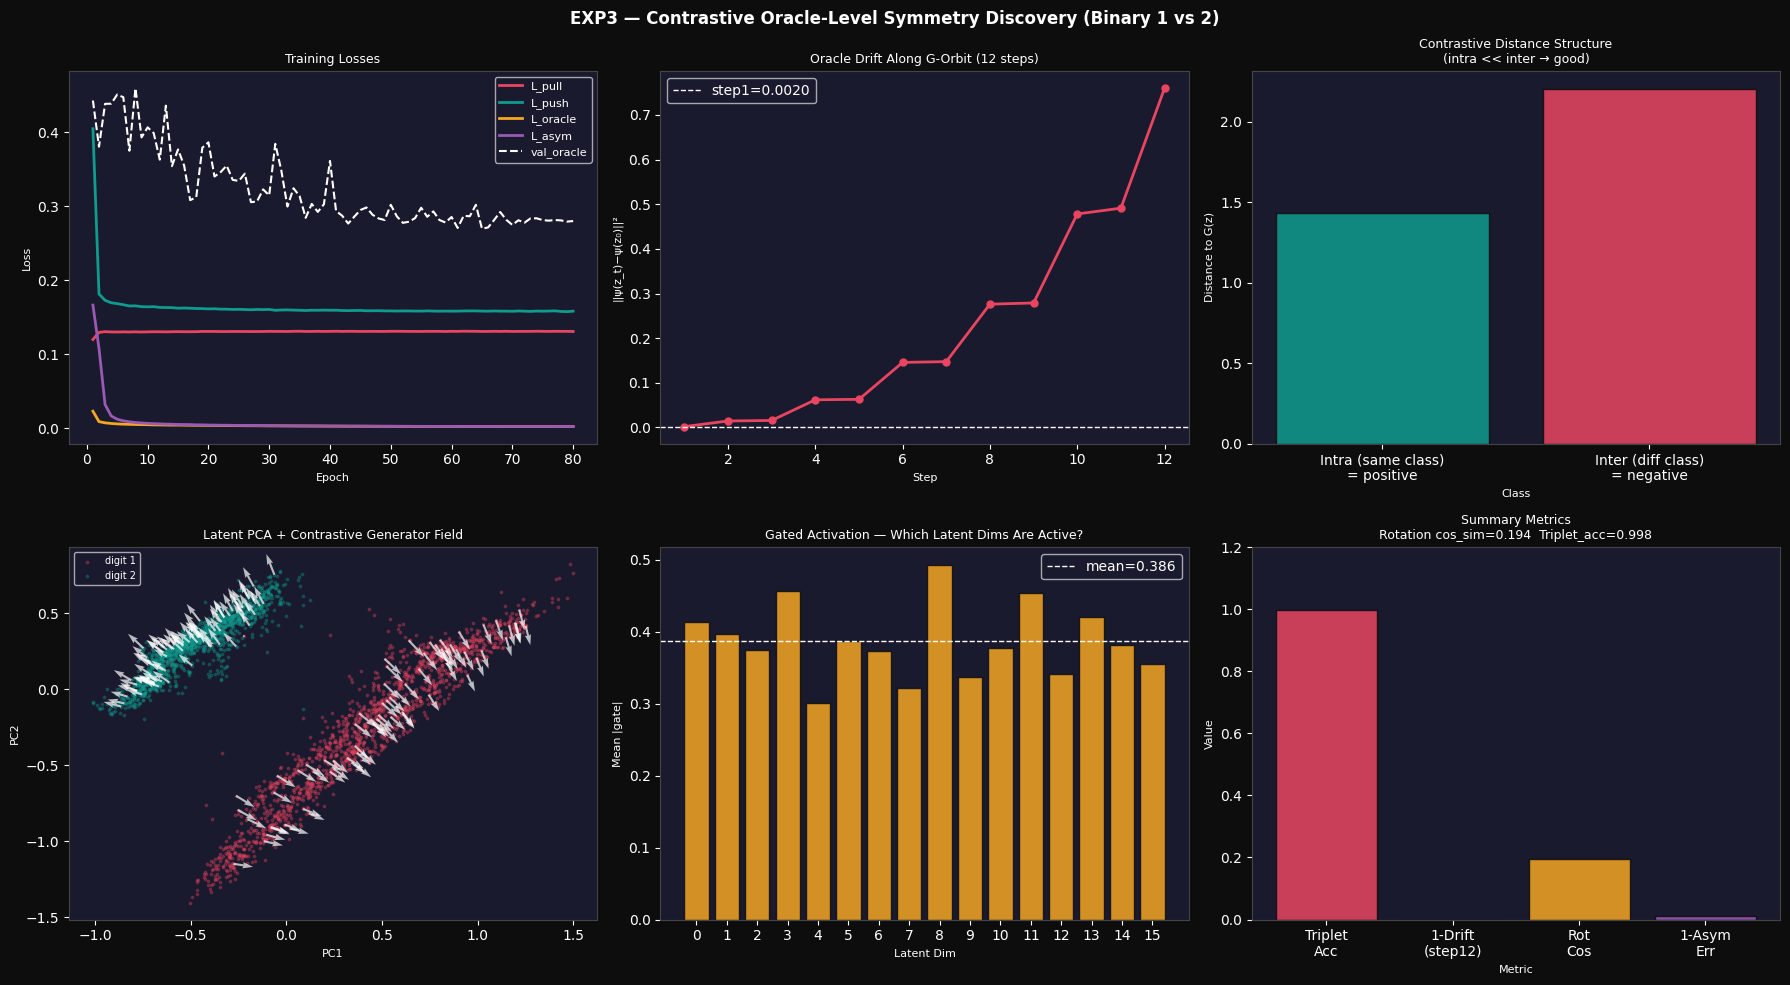

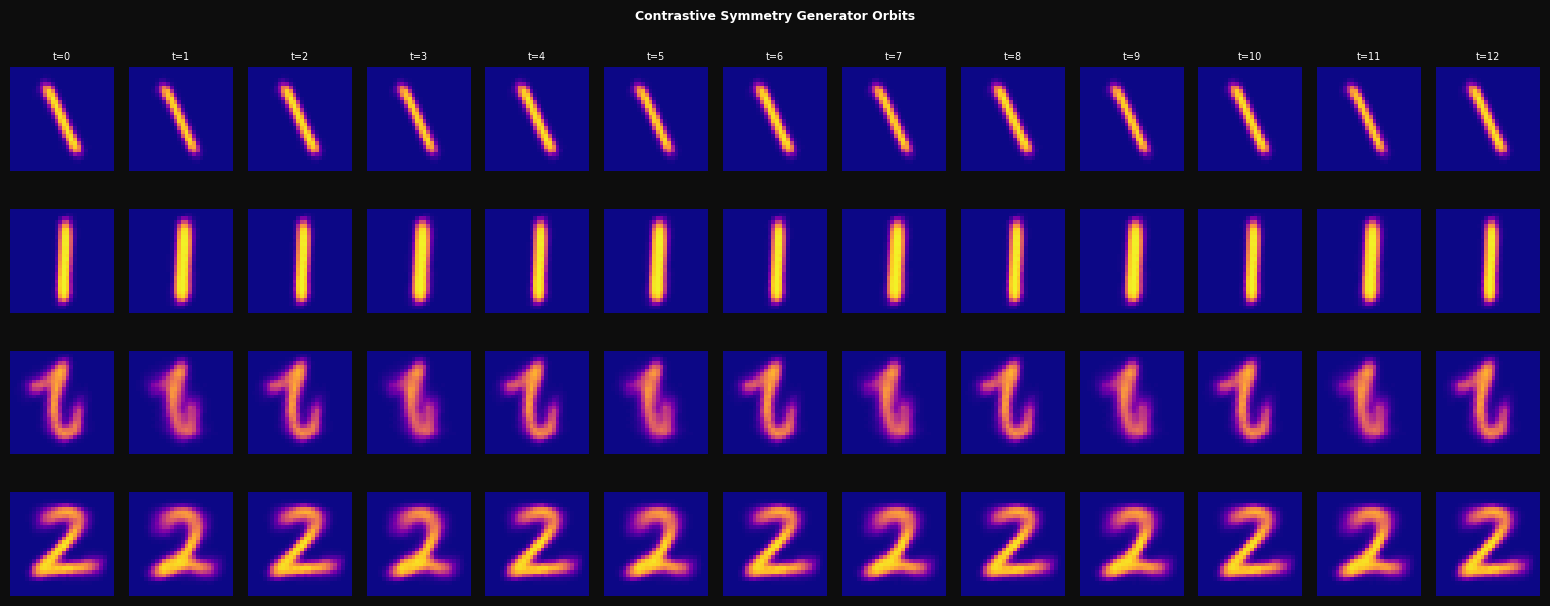


✅ EXP3 — Contrastive Symmetry Discovery complete
   Rotation cosine sim: 0.1942  |  Triplet acc: 0.9980


In [11]:
DARK = "#0d0d0d"; PANEL = "#1a1a2e"
 
def _ax(ax, title="", xl="", yl=""):
    ax.set_facecolor(PANEL); ax.tick_params(colors="white")
    for s in ax.spines.values(): s.set_edgecolor("#444")
    if title: ax.set_title(title, color="white", fontsize=9)
    if xl:    ax.set_xlabel(xl, color="white", fontsize=8)
    if yl:    ax.set_ylabel(yl, color="white", fontsize=8)
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor=DARK)
fig.suptitle("EXP3 — Contrastive Oracle-Level Symmetry Discovery (Binary 1 vs 2)",
             color="white", fontsize=12, fontweight="bold")
 
ep_x = range(1, EPOCHS_G + 1)
_ax(axes[0,0], "Training Losses", "Epoch", "Loss")
axes[0,0].plot(ep_x, history["pull"],  color="#e94560", lw=2, label="L_pull")
axes[0,0].plot(ep_x, history["push"],  color="#0f9b8e", lw=2, label="L_push")
axes[0,0].plot(ep_x, history["oracle"],color="#f5a623", lw=2, label="L_oracle")
axes[0,0].plot(ep_x, history["asym"],  color="#9b59b6", lw=2, label="L_asym")
axes[0,0].plot(ep_x, history["val_oracle"], color="white", lw=1.5, ls="--", label="val_oracle")
axes[0,0].legend(facecolor=PANEL, labelcolor="white", fontsize=8)
 
_ax(axes[0,1], "Oracle Drift Along G-Orbit (12 steps)", "Step", "||ψ(z_t)−ψ(z₀)||²")
axes[0,1].plot(range(1, 13), drift_curve, color="#e94560", lw=2, marker="o", ms=5)
axes[0,1].axhline(drift_curve[0], color="white", ls="--", lw=1, label=f"step1={drift_curve[0]:.4f}")
axes[0,1].legend(facecolor=PANEL, labelcolor="white")
 
_ax(axes[0,2], "Intra vs Inter Class Distance After G-Step", "Class", "Distance to G(z)")
axes[0,2].bar(["Intra (same class)\n= positive", "Inter (diff class)\n= negative"],
              [d_intra, d_inter], color=["#0f9b8e", "#e94560"], alpha=0.85, edgecolor=DARK)
axes[0,2].set_title("Contrastive Distance Structure\n(intra << inter → good)",
                     color="white", fontsize=9)
axes[0,2].tick_params(colors="white")
 
pca    = PCA(n_components=2).fit(Z_te[:3000].numpy())
z2_all = pca.transform(Z_te[:3000].numpy())
c_all  = C_te[:3000].numpy()
 
_ax(axes[1,0], "Latent PCA + Contrastive Generator Field", "PC1", "PC2")
axes[1,0].scatter(z2_all[c_all==0,0], z2_all[c_all==0,1], s=3, alpha=0.3, color="#e94560", label="digit 1")
axes[1,0].scatter(z2_all[c_all==1,0], z2_all[c_all==1,1], s=3, alpha=0.3, color="#0f9b8e", label="digit 2")
idx_q = np.random.choice(3000, 150, replace=False)
z_q   = torch.from_numpy(Z_te[:3000][idx_q].numpy()).to(device)
with torch.no_grad():
    gv = G(z_q).cpu().numpy() @ pca.components_.T
axes[1,0].quiver(z2_all[idx_q,0], z2_all[idx_q,1], gv[:,0], gv[:,1],
                 color="white", alpha=0.7, scale=25, width=0.004)
axes[1,0].legend(facecolor=PANEL, labelcolor="white", fontsize=7)
 
_ax(axes[1,1], "Gated Activation — Which Latent Dims Are Active?", "Latent Dim", "Mean |gate|")
with torch.no_grad():
    z_sample = Z_te[:500].to(device)
    gate_acts = G.gate(z_sample).mean(0).cpu().numpy()
bars = axes[1,1].bar(range(LATENT_DIM), gate_acts, color="#f5a623", alpha=0.85, edgecolor=DARK)
axes[1,1].axhline(gate_acts.mean(), color="white", ls="--", lw=1, label=f"mean={gate_acts.mean():.3f}")
axes[1,1].set_xticks(range(LATENT_DIM))
axes[1,1].legend(facecolor=PANEL, labelcolor="white")
 
_ax(axes[1,2], f"Summary Metrics\nRotation cos_sim={cos_sim:.3f}  Triplet_acc={triplet_acc:.3f}",
    "Metric", "Value")
metrics = {"Triplet\nAcc": triplet_acc, "1-Drift\n(step12)": max(0, 1-drift_curve[-1]*10),
           "Rot\nCos": cos_sim, "1-Asym\nErr": max(0, 1-asym_err)}
axes[1,2].bar(metrics.keys(), metrics.values(),
              color=["#e94560","#0f9b8e","#f5a623","#9b59b6"], alpha=0.85, edgecolor=DARK)
axes[1,2].set_ylim(0, 1.2)
 
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "results.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
plt.show()
 
# Orbit visualization
@torch.no_grad()
def plot_orbits(n_samples=4, n_steps=13):
    idx1 = (C_te==0).nonzero(as_tuple=True)[0][:n_samples//2]
    idx2 = (C_te==1).nonzero(as_tuple=True)[0][:n_samples//2]
    pool = torch.cat([idx1, idx2]).tolist()
    fig, axes = plt.subplots(n_samples, n_steps,
                              figsize=(n_steps*1.2, n_samples*1.6), facecolor=DARK)
    fig.suptitle("Contrastive Symmetry Generator Orbits",
                 color="white", fontsize=9, fontweight="bold")
    for row, idx in enumerate(pool):
        z = Z_te[idx:idx+1].to(device)
        label = "digit 1" if C_te[idx].item() == 0 else "digit 2"
        for col in range(n_steps):
            img = vae.decoder(z).clamp(0.,1.).cpu().squeeze().numpy()
            axes[row, col].imshow(img, cmap="plasma", vmin=0, vmax=1)
            axes[row, col].axis("off")
            if col == 0: axes[row, col].set_ylabel(label, color="white", fontsize=7, rotation=0, labelpad=30)
            if row == 0: axes[row, col].set_title(f"t={col}", color="white", fontsize=7)
            if col < n_steps-1: z = z + EPS_STEP * G(z)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "orbits.png"), dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
 
plot_orbits()
print(f"\n✅ EXP3 — Contrastive Symmetry Discovery complete")
print(f"   Rotation cosine sim: {cos_sim:.4f}  |  Triplet acc: {triplet_acc:.4f}")